# `fmri-6`: Functional connectivity
This demo introduces functional connectivity analysis on resting-state data. Resting-state paradigms generally have no external experimental stimulus or behavioral output; however, brain systems will continue to fluctuate over time as we ruminate. Functional connectivity analysis captures correlations between the intrinsic flucutations of different brain areas across time. Due to the lack of external variables, resting-state data are typically limited to functional connectivity analyses; on the other hand, functional connectivity analyses can be applied to non-resting-state data (e.g. recall the ISFC analysis from `fmri-11`). We'll first perform a seed-based connectivity analysis, then use the full functional connectivity matrix to create a functional parcellation of cortex.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The NKI-Rockland sample
We'll explore functional connectivity analysis on a public resting-state dataset provided by [Nooner et al., 2012](https://doi.org/10.3389/fnins.2012.00152). These data comprise ~10-minute resting-state runs with a rapid TR of 0.645 s.  These data were preprocessed and spatially normalized to the fsaverage5 cortical surface template. We'll begin with one subject. We'll also use an anatomically-defined surface-based cortical parcellation to guide our analysis ([Destrieux et al., 2010](https://doi.org/10.1016/j.neuroimage.2010.06.010)).

In [2]:
# Load NKI-Rockland resting-state dataset
from nilearn import datasets

data_dir = '/Users/lingweicao/Documents/Princeton/Coursework/502B/neu502b-2025/nilearn-data'
nki_dataset = datasets.fetch_surf_nki_enhanced(n_subjects=1,
                                               data_dir=data_dir)

# Load the fsaverage5 cortical surface template
fsaverage5 = datasets.fetch_surf_fsaverage()

# Load Destrieux anatomical atlas for fsaverage5
destrieux_atlas = datasets.fetch_atlas_surf_destrieux(data_dir=data_dir)
parcellation = destrieux_atlas['map_left']
labels = destrieux_atlas['labels']

[get_dataset_dir] Dataset created in /Users/lingweicao/Documents/Princeton/Coursework/502B/ne
u502b-2025/nilearn-data/nki_enhanced_surface

[fetch_single_file] Downloading data from 
https://www.nitrc.org/frs/download.php/8470/pheno_nki_nilearn.csv ...

[fetch_single_file]  ...done. (0 seconds, 0 min)

[fetch_single_file] Downloading data from 
https://www.nitrc.org/frs/download.php/8261/A00028185_rh_preprocessed_fsaverage5_fwhm6.gii 
...

\[_chunk_report_] Downloaded 5251072 of 42412120 bytes (12.4%%,    7.4s remaining)

...

[get_dataset_dir] Dataset created in /Users/lingweicao/Documents/Princeton/Coursework/502B/ne
u502b-2025/nilearn-data/destrieux_surface

[fetch_single_file] Downloading data from 
https://www.nitrc.org/frs/download.php/9343/lh.aparc.a2009s.annot ...

[fetch_single_file]  ...done. (0 seconds, 0 min)

[fetch_single_file] Downloading data from 
https://www.nitrc.org/frs/download.php/9342/rh.aparc.a2009s.annot ...

[fetch_single_file]  ...done. (0 seconds, 0 min)

In [3]:
# Extract functional data
from nilearn import surface

func_data = surface.load_surf_data(nki_dataset['func_left'][0]).T
print(f"Functional data shape: {func_data.shape}")

Functional data shape: (895, 10242)


/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/nilearn/plotting/surf_plotting.py:495: UserWarning: You provided a non integer threshold but configured the colorbar to use integer formatting.
  warn(


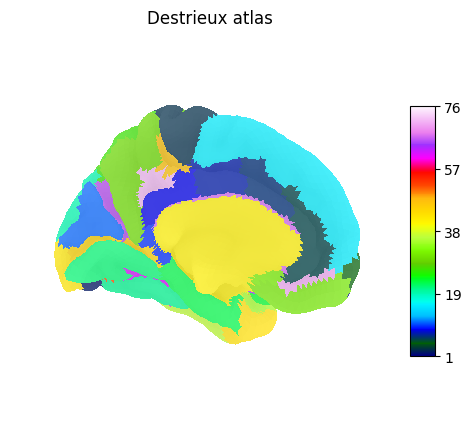

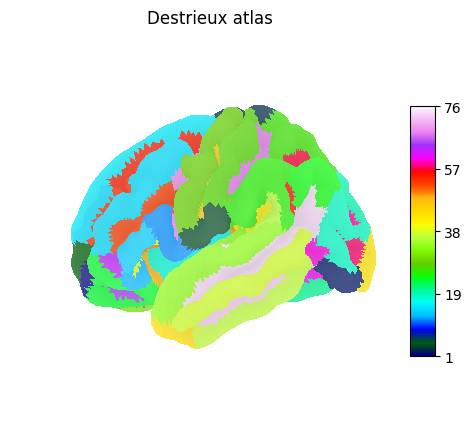

In [4]:
# Plot Destrieux atlas
from nilearn.plotting import plot_surf_roi
plot_surf_roi(fsaverage5['pial_left'], roi_map=parcellation,
                   hemi='left', view='medial', colorbar=True,
                   bg_map=fsaverage5['sulc_left'], bg_on_data=True,
                   darkness=.5, title='Destrieux atlas');

plot_surf_roi(fsaverage5['pial_left'], roi_map=parcellation,
                   hemi='left', view='lateral', colorbar=True,
                   bg_map=fsaverage5['sulc_left'], bg_on_data=True,
                   darkness=.5, title='Destrieux atlas');

### Seed-based functional connectivity
In one of the simplest variations of functional connectivity analysis, we first choose a "seed" region and then compute the correlations between the seed time series and other brain areas. Here we compute the correlation between the average time series from our seed region and all other voxel time series in the cortex. We'll start with the dorsal part of the posterior cingulate—a member of the default-mode network (DMN)—but can try some other seed regions as well.

In [5]:
# Extract seed region via parcellation label
roi_label = b'G_cingul-Post-dorsal'

roi_vertices = np.where(parcellation == labels.index(roi_label))[0]

Plot the ROI on the cortical surface using `plot_surf_roi` and then plot the mean BOLD time series for the ROI.

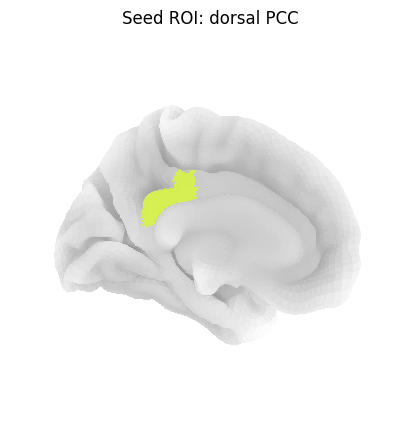

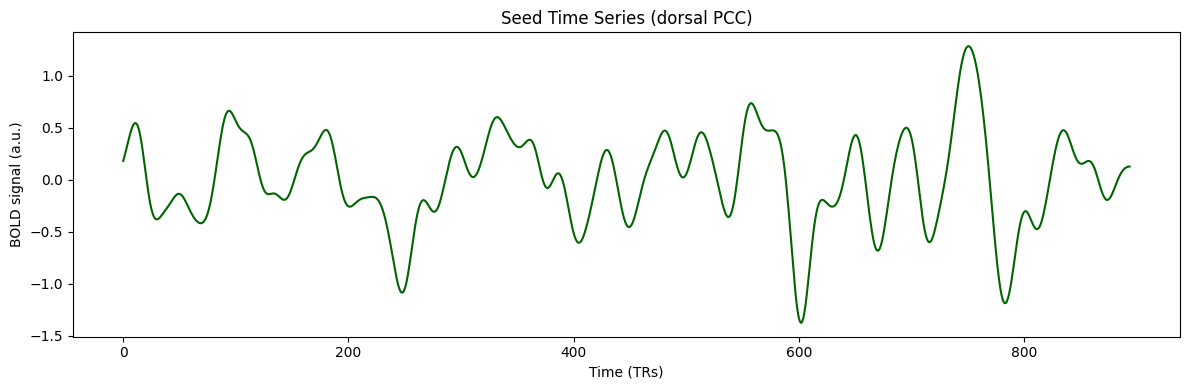

In [8]:
# Transform ROI indices in ROI map
roi_map = np.zeros(parcellation.shape[0], dtype=int)
roi_map[roi_vertices] = 1

# Plot ROI on surface:
plot_surf_roi(
    surf_mesh=fsaverage5['pial_left'],
    roi_map=roi_map,
    hemi='left',
    view='medial',
    bg_map=fsaverage5['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    title='Seed ROI: dorsal PCC'
)

# Extract time series from seed region:
seed_ts = func_data[:, roi_vertices].mean(axis=1)

# Plot seed time series:
plt.figure(figsize=(12, 4))
plt.plot(seed_ts, color='darkgreen')
plt.xlabel('Time (TRs)')
plt.ylabel('BOLD signal (a.u.)')
plt.title('Seed Time Series (dorsal PCC)')
plt.tight_layout()
plt.show()


Now that we've extracted the time series for our seed region, we loop through every voxel in the brain and compute the Pearson correlation between time series. This results in a seed-based functional connectivity map for our selected seed region.

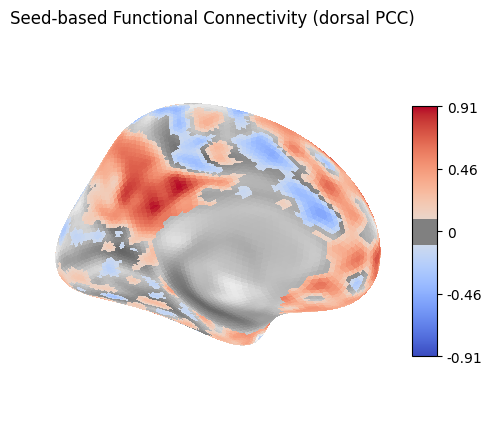

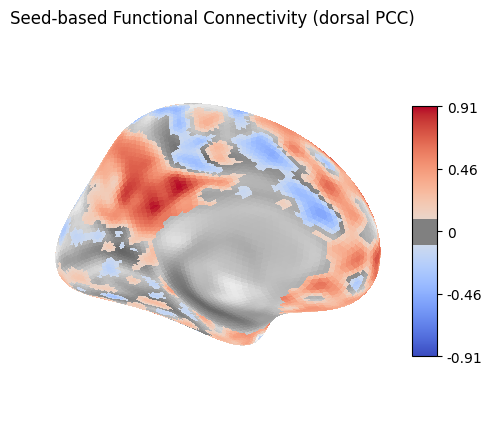

In [12]:
# Compute seed-based functional connectivity map:
from scipy.stats import pearsonr

# Initialize array to hold correlation values
n_vertices = func_data.shape[1]
seed_fc = np.zeros(n_vertices)

seed_ts = seed_ts.astype(np.float32)
func_data = func_data.astype(np.float32)


# Compute correlation of seed with each vertex
for v in range(n_vertices):
    ts = func_data[:, v]
    if np.std(ts) == 0:
        seed_fc[v] = np.nan
    else:
        r, _ = pearsonr(seed_ts, ts)
        seed_fc[v] = r


# Plot surface map:
from nilearn.plotting import plot_surf_stat_map

plot_surf_stat_map(
    surf_mesh=fsaverage5['infl_left'],
    stat_map=seed_fc,
    hemi='left',
    view='medial',
    bg_map=fsaverage5['sulc_left'],
    cmap='coolwarm',
    threshold=0.1,  # show only moderate-to-strong correlations
    colorbar=True,
    title='Seed-based Functional Connectivity (dorsal PCC)'
)


### Functional connectivity matrices
We can extend the logic of seed-based functional connectivity to every voxel in the brain, yielding a $v\times v$ matrix where $v$ is the number of voxels (or regions) in the brain. We can use `numpy`'s `corrcoef` to compute the full correlation matrix (let's call it `fc_mat`), then reorganize this matrix to reflect the anatomically-defined parcels in our atlas. This captures a certain functional network strucure in the brain. Note that the diagonal of this matrix is not meaningful as it represents the time series at each brain area correlated with itself (i.e. $r = 1$); on the other hand, each row of this matrix corresponds to the seed-based functional connectivity map for the voxel or brain area at that row.

/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


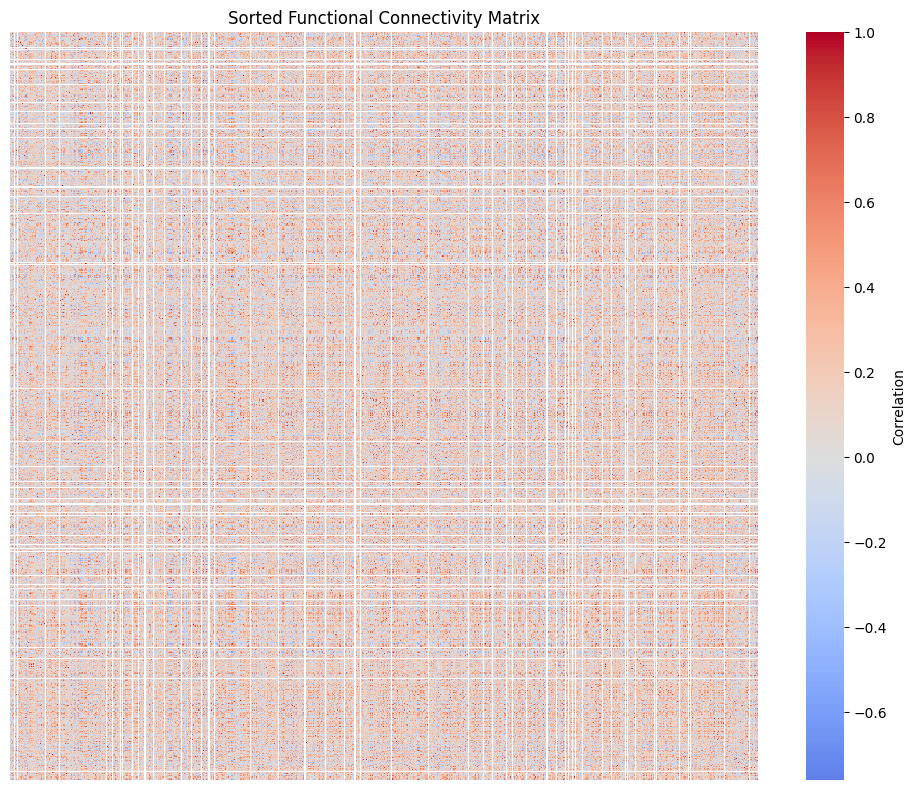

In [13]:
# Compute full correlation matrix:
fc_mat = np.corrcoef(func_data.T)  # shape: (n_vertices, n_vertices)

# Sort data by ROI
medial_label = labels.index(b'Medial_wall')
sorter = np.argsort(parcellation[parcellation != medial_label])
fc_sorted = fc_mat[sorter][:, sorter]

# Plot sorted connectivity matrix:
plt.figure(figsize=(10, 8))
sns.heatmap(fc_sorted, cmap='coolwarm', center=0, square=True,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'})
plt.title('Sorted Functional Connectivity Matrix')
plt.tight_layout()
plt.show()


Next, we'll load in data for 5 subjects. We'll compute the full functional connectivity matrix for each subject. Note that we can't meaningfully average the time series across subjects because mental events and brain states are happenning at different times across subjects (since there's no shared stimulus driving the brain). However, we *can* average the functional connectivity matrices across subjects.

In [14]:
# Load in a larger sample of subjects
n_subjects = 5

nki_dataset = datasets.fetch_surf_nki_enhanced(n_subjects=n_subjects,
                                               data_dir=data_dir)

[get_dataset_dir] Dataset found in /Users/lingweicao/Documents/Princeton/Coursework/502B/neu5
02b-2025/nilearn-data/nki_enhanced_surface

[fetch_single_file] Downloading data from 
https://www.nitrc.org/frs/download.php/8263/A00033747_rh_preprocessed_fsaverage5_fwhm6.gii 
...

\[_chunk_report_] Downloaded 13107200 of 42437884 bytes (30.9%%,    2.2s remaining)

\[_chunk_report_] Downloaded 21299200 of 42437884 bytes (50.2%%,    2.0s remaining)

\[_chunk_report_] Downloaded 28622848 of 42437884 bytes (67.4%%,    1.5s remaining)

...

[fetch_single_file] Downloading data from 
https://www.nitrc.org/frs/download.php/8268/A00035840_lh_preprocessed_fsaverage5_fwhm6.gii 
...

\[_chunk_report_] Downloaded 15122432 of 42210360 bytes (35.8%%,    1.8s remaining)

\[_chunk_report_] Downloaded 27983872 of 42210360 bytes (66.3%%,    1.0s remaining)

\[_chunk_report_] Downloaded 36069376 of 42210360 bytes (85.5%%,    0.5s remaining)

[fetch_single_file]  ...done. (4 seconds, 0 min)

In [15]:
# Compute connectome for each subject and average:
from numpy import corrcoef

# List to store per-subject FC matrices
fc_matrices = []

for i in range(n_subjects):
    # Load and transpose functional data to (n_timepoints, n_vertices)
    func_data = surface.load_surf_data(nki_dataset['func_left'][i]).T
    func_data = func_data.astype(np.float32)  # ensure correct type
    
    # Compute FC matrix (correlation across time)
    fc = corrcoef(func_data.T)
    fc_matrices.append(fc)

# Stack and average
fc_mean = np.mean(fc_matrices, axis=0)


/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


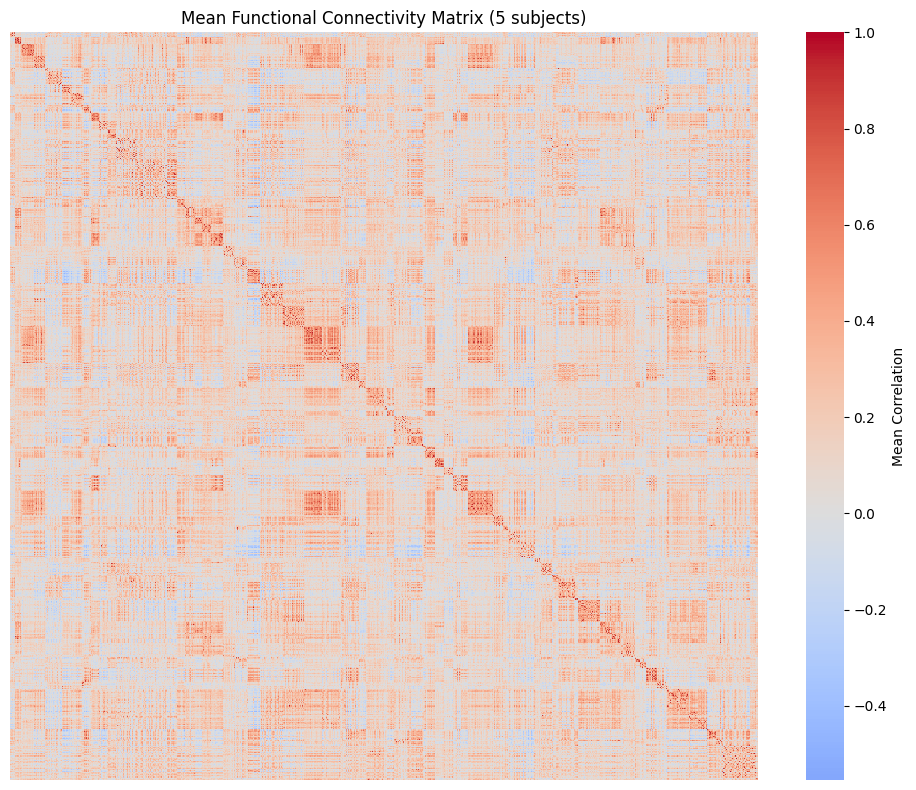

In [16]:
# Remove medial wall:
# Get medial wall label
medial_label = labels.index(b'Medial_wall')

# Get valid (non-medial wall) vertex indices
valid_vertices = np.where(parcellation != medial_label)[0]

# Subset the mean FC matrix
fc_valid = fc_mean[valid_vertices][:, valid_vertices]

# Sort by anatomical ROIs:
sorter = np.argsort(parcellation[valid_vertices])
fc_sorted = fc_valid[sorter][:, sorter]

# Plot mean connectivity matrix across subjects:
plt.figure(figsize=(10, 8))
sns.heatmap(fc_sorted, cmap='coolwarm', center=0, square=True,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Mean Correlation'})
plt.title('Mean Functional Connectivity Matrix (5 subjects)')
plt.tight_layout()
plt.show()


Let's check how reliable the functional network structure is across subjects. We'll vectorize the off-diagonal connectivity values for each subject, then compute the pairwise correlations between the connectivity matrices for all subjects. This yields a $N\times N$ matrix where $N$ is the number of subjects in our sample.

In [17]:
# Check correlation between individual subject FC matrices
from scipy.spatial.distance import squareform

# Vectorize off-diagonal connnectivity values:

# Initialize list to store vectorized FC matrices for all subjects
fc_vectors = []

# Loop through each subject to compute FC matrix and extract lower triangle
for i in range(n_subjects):
    # Load and transpose functional data
    func_data = surface.load_surf_data(nki_dataset['func_left'][i]).T
    func_data = func_data.astype(np.float32)

    # Compute full FC matrix
    fc = np.corrcoef(func_data.T)

    # Remove medial wall vertices
    medial_label = labels.index(b'Medial_wall')
    valid_vertices = np.where(parcellation != medial_label)[0]
    fc = fc[valid_vertices][:, valid_vertices]

    # Vectorize lower triangle (excluding diagonal)
    fc_vec = squareform(fc, checks=False)
    fc_vectors.append(fc_vec)

# Stack vectorized connectivity matrices:
# Convert list to matrix of shape (n_subjects, n_connections)
fc_vectors = np.vstack(fc_vectors)

# Compute correlations between connectomes:
subject_corr = np.corrcoef(fc_vectors)


/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/neu502b/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


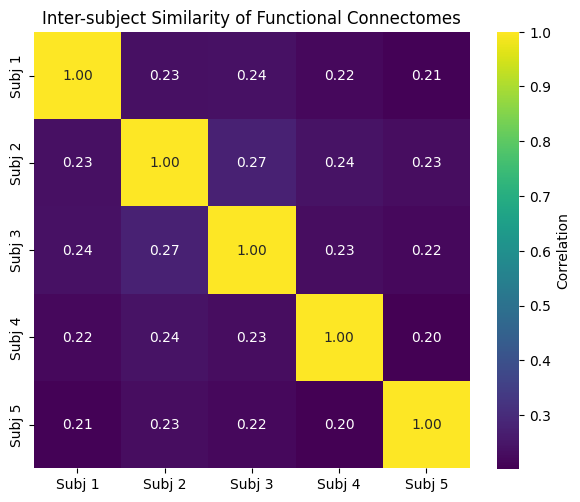

Mean inter-subject FC similarity: 0.230


In [18]:
# Plot reliability of network structure across subjects:
plt.figure(figsize=(6, 5))
sns.heatmap(subject_corr, annot=True, fmt=".2f", cmap='viridis', square=True,
            xticklabels=[f'Subj {i+1}' for i in range(n_subjects)],
            yticklabels=[f'Subj {i+1}' for i in range(n_subjects)],
            cbar_kws={'label': 'Correlation'})
plt.title('Inter-subject Similarity of Functional Connectomes')
plt.tight_layout()
plt.show()

# Get mean correlation across pairs of subjects:
triu = np.triu_indices(n_subjects, k=1)
mean_fc_reliability = subject_corr[triu].mean()
print(f"Mean inter-subject FC similarity: {mean_fc_reliability:.3f}")


### Functional parcellation
We can use clustering algorithms to "discover" structure in the full connectivity matrices. Use a clustering algorithm (e.g. `AgglomerativeClustering` or `KMeans` from `sklearn`) to cluster the connectivity matrix. For the sake of expediency, pick an arbitrary number of clusters (e.g. `n_clusters=7`). This results in a cluster label for every cortical voxel. This functional parcellation captures some well-known whole-brain networks.

In [20]:
# Cluster functional connectivity:
from sklearn.cluster import AgglomerativeClustering

# We'll use the mean functional connectivity matrix across subjects
# Make sure we're clustering on valid (non-medial wall) vertices only
fc_for_clustering = fc_mean[valid_vertices][:, valid_vertices]

# Agglomerative clustering on connectivity profiles (rows)
n_clusters = 7
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
cluster_labels = clustering.fit_predict(fc_for_clustering)


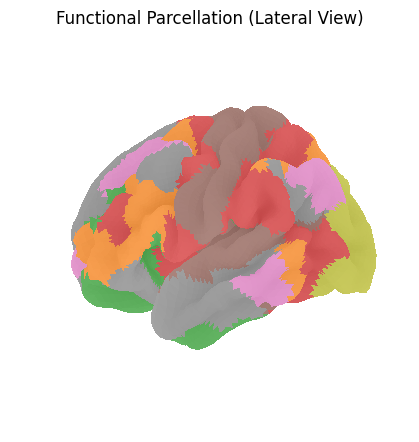

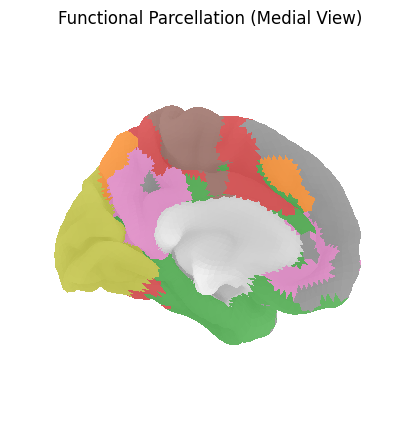

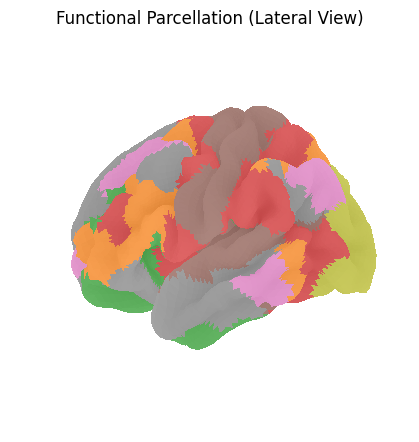

In [21]:
# Reinsert cluster labels into full map:
# Create an array with same length as total number of vertices
full_cluster_map = np.zeros(parcellation.shape[0], dtype=int)

# Fill in cluster labels for non-medial wall vertices
full_cluster_map[valid_vertices] = cluster_labels + 1  # shift by 1 for visual contrast (0 = background)

# Plot clusters:
from nilearn.plotting import plot_surf_roi

# Plot functional parcellation (medial view)
plot_surf_roi(
    surf_mesh=fsaverage5['pial_left'],
    roi_map=full_cluster_map,
    hemi='left',
    view='medial',
    bg_map=fsaverage5['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    title='Functional Parcellation (Medial View)',
    cmap='tab10'
)

# Plot functional parcellation (lateral view)
plot_surf_roi(
    surf_mesh=fsaverage5['pial_left'],
    roi_map=full_cluster_map,
    hemi='left',
    view='lateral',
    bg_map=fsaverage5['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    title='Functional Parcellation (Lateral View)',
    cmap='tab10'
)


#### References

* Destrieux, C., Fischl, B., Dale, A., & Halgren, E. (2010). Automatic parcellation of human cortical gyri and sulci using standard anatomical nomenclature. *NeuroImage*, *53*(1), 1-15. https://doi.org/10.1016/j.neuroimage.2010.06.010

* Nooner, K. B., Colcombe, S. J., Tobe, R. H., Mennes, M., Benedict, M. M., Moreno, A. L., Panek, L. J., Brown, S., Zavitz, S. T., Li, Q., Sikka, S., Gutman, D., Bangaru, S., Tziona Schlachter, R., Kamiel, S. M., Anwar, A. R., Hinz, C. M., Kaplan, M. S., Rachlin, A. B., Adelsberg, S., Cheung, B., Khanuja, R., Yan, C., Cradddock, R. C., Calhoun, V., Courtney, W., King, M., Wood, D., Cox, C. L., Kelly, A. M. C., Di Martino, A., Petkova, E., Reiss, P. T., Duan, N., Thomsen, D., Biswal, B., Coffey, B., Hoptman, M. J., Javitt, D. C., Pomara, N., Sidtis, J. J., Koplewicz, H. S., Castellanos, F. X., Leventhal, B. L., & Milham, M. (2012). The NKI-Rockland sample: a model for accelerating the pace of discovery science in psychiatry. *Frontiers in Neuroscience*, *6*, 152. https://doi.org/10.3389/fnins.2012.00152